Training an FNN neural network with scaled dataframe

In [2]:
!pip install keras
!pip install tensorflow
!pip install scikeras

Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None


In [3]:
#Importing modules and librarie
import tensorflow.keras as keras
import pandas as pd
import numpy as np
from scikeras.wrappers import KerasClassifier

2025-08-01 12:56:02.851864: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-01 12:56:02.881937: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754067362.917574 1600915 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754067362.927948 1600915 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754067362.956164 1600915 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [4]:
#Loading dataframe 
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Typing dataset/nn.csv")


In [5]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons
0,-0.926613,2.035899,-1.196553,0.383238,0.014051,False
1,-0.926613,-1.090005,0.539266,-0.303976,-0.221183,True
2,1.079200,2.139918,1.407176,-0.423359,-1.432679,True
3,1.079200,-0.465891,-0.328644,-0.483050,-0.726116,False
4,1.079200,-0.359205,-0.328644,1.309982,1.461643,True
...,...,...,...,...,...,...
51722,-0.926613,1.827861,-1.196553,-1.977626,-0.726116,True
51723,-0.926613,-0.777948,-1.196553,-0.423359,-0.355602,True
51724,-0.926613,-1.610100,-1.196553,1.728585,2.201810,True
51725,1.079200,-0.569910,-0.328644,-0.542741,-1.298260,False


In [6]:
#Dropping the hand and direction columns since they might not be predictive
df = df.drop(columns = ["Hand", "Direction"])

In [7]:
df["Parkinsons"].isna().sum()

0

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
df["Parkinsons"].isna().sum()

0

In [10]:
df["Parkinsons"].value_counts()

Parkinsons
False    26956
True     24771
Name: count, dtype: int64

In [11]:
#Dividing into train_test_split and defining labels
df["Parkinsons"] = df["Parkinsons"].astype(int)

print(df["Parkinsons"].value_counts())

y = df["Parkinsons"]

X = df.drop(columns=["Parkinsons"])

from imblearn.over_sampling import SMOTE
from collections import Counter

# Assume X and y are your features and labels
print("Original class distribution:", Counter(y))

rus = SMOTE(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled class distribution:", Counter(y_resampled))

X_train, X_test, y_train , y_test = train_test_split(X_resampled, y_resampled, random_state=42, test_size=0.2)


Parkinsons
0    26956
1    24771
Name: count, dtype: int64
Original class distribution: Counter({0: 26956, 1: 24771})


/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled class distribution: Counter({0: 26956, 1: 26956})


In [12]:
#Making sure my featurs are int or floats
print(X_train.dtypes)

HoldTime       float64
LatencyTime    float64
FlightTime     float64
dtype: object


In [13]:
print(y)

0        0
1        1
2        1
3        0
4        1
        ..
51722    1
51723    1
51724    1
51725    0
51726    0
Name: Parkinsons, Length: 51727, dtype: int64


In [14]:
#Defining the loss function  and optimizer
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

optim = keras.optimizers.Adam(learning_rate=0.001)


2025-08-01 12:56:08.948462: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
#Creating the NN Architecture 


nn_model = keras.Sequential()

#Input layer 
input_layer = keras.layers.InputLayer(input_shape = (len(X_train.columns),))
nn_model.add(input_layer)

#Hidden layer 1
hidden_layer_1 = keras.layers.Dense(units = 128, activation="relu")
nn_model.add(hidden_layer_1)

#Hidden layer 2
hidden_layer_2 = keras.layers.Dense(units=64, activation="relu")
nn_model.add(hidden_layer_2)

#hidden layer 3
hidden_layer_3 = keras.layers.Dense(units=32, activation="relu")
nn_model.add(hidden_layer_3)
dropout = keras.layers.Dropout(0.2)
nn_model.add(dropout)

#extra hidden layer 
hidden_layer_5 = keras.layers.Dense(units=16, activation="relu")
nn_model.add(hidden_layer_5)
nn_model.add(keras.layers.Dropout(0.2))

#hidden layer 4 / output 5
hidden_layer_4 = keras.layers.Dense(units=1, activation="sigmoid")
nn_model.add(hidden_layer_4)


 #Compiling the model
nn_model.compile(optimizer=optim, loss=loss_fn, metrics=["accuracy"])



/users/imbahndu/.local/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [16]:
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#Fitting the model
num_epochs = 50
model = nn_model.fit(X_train, y_train, epochs=num_epochs, validation_split=0.3)

Epoch 1/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5155 - loss: 0.6923 - val_accuracy: 0.5408 - val_loss: 0.6900
Epoch 2/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5293 - loss: 0.6902 - val_accuracy: 0.5463 - val_loss: 0.6887
Epoch 3/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5367 - loss: 0.6892 - val_accuracy: 0.5418 - val_loss: 0.6884
Epoch 4/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5348 - loss: 0.6882 - val_accuracy: 0.5446 - val_loss: 0.6873
Epoch 5/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5394 - loss: 0.6879 - val_accuracy: 0.5493 - val_loss: 0.6868
Epoch 6/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5418 - loss: 0.6873 - val_accuracy: 0.5434 - val_loss: 0.6871
Epoch 7/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5346 - loss: 0.6884 - val_accuracy: 0.5484 - val_loss: 0.6859
Epoch 8/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5388 - loss: 0.6877 - val_accuracy: 0.

In [18]:
#Evaluating the model's accuracy and loss over time through visualizations
print(model.history.keys())
import matplotlib.pyplot as plt

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


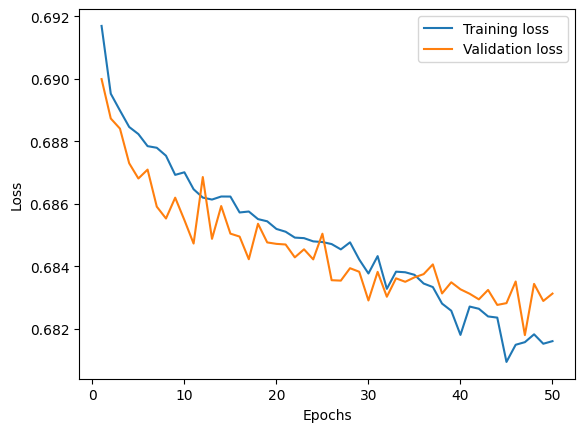

In [19]:
#Plotting loss 
plt.plot(range(1, num_epochs+1), model.history['loss'], label="Training loss")
plt.plot(range(1, num_epochs+1), model.history['val_loss'], label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

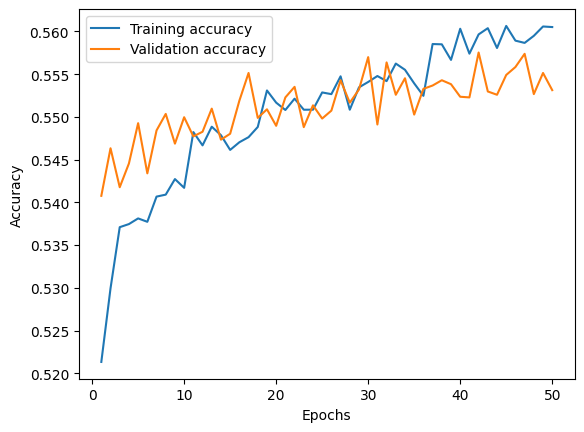

In [20]:
plt.plot(range(1, num_epochs+1), model.history['accuracy'], label="Training accuracy")
plt.plot(range(1, num_epochs+1), model.history['val_accuracy'], label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [21]:
loss, accuracy = nn_model.evaluate(X_test,y_test)
print("Loss is ", loss)
print("Accuracy is", accuracy)

337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5442 - loss: 0.6877
Loss is  0.6853244304656982
Accuracy is 0.5474357604980469


In [22]:
#Predictions on X_test and setting threshold to 
predict_label = nn_model.predict(X_test)
predict_label_int = (predict_label >= 0.5).astype(int)

337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [23]:
#Confusion matrix and classification report 

print(confusion_matrix(y_test, predict_label_int))

print(classification_report(y_test, predict_label_int))

print(accuracy_score(y_test, predict_label_int))

[[3088 2304]
 [2576 2815]]
              precision    recall  f1-score   support

           0       0.55      0.57      0.56      5392
           1       0.55      0.52      0.54      5391

    accuracy                           0.55     10783
   macro avg       0.55      0.55      0.55     10783
weighted avg       0.55      0.55      0.55     10783

0.5474357785402949


/tmp/ipykernel_1600915/78027907.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<function matplotlib.pyplot.show(close=None, block=None)>

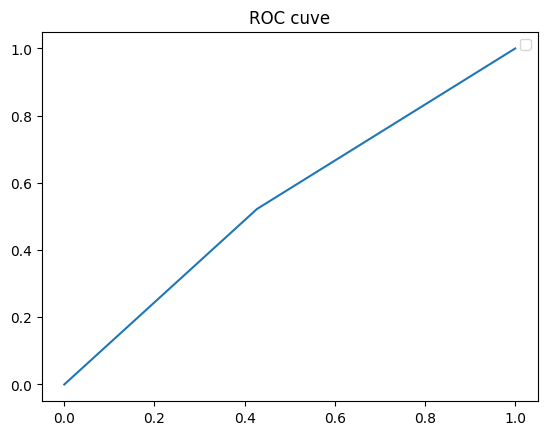

In [24]:
from sklearn.metrics import roc_curve
import seaborn as sns

fpr, tpr, threshold = roc_curve(y_test, predict_label_int)
sns.lineplot(x=fpr, y=tpr)
plt.title("ROC cuve")
plt.legend()
plt.show